In [32]:
import requests
import pandas as pd

# Start a session
session = requests.Session()

query_url = "https://services3.arcgis.com/xpR2E2r2KmCE5hF3/ArcGIS/rest/services/survey123_a2c60388714343fdba1dd544d47ca769/FeatureServer/0/query?where=1%3D1&objectIds=&geometry=&geometryType=esriGeometryEnvelope&inSR=&spatialRel=esriSpatialRelIntersects&resultType=none&distance=0.0&units=esriSRUnit_Meter&outDistance=&relationParam=&returnGeodetic=false&outFields=*&returnGeometry=false&featureEncoding=esriDefault&multipatchOption=xyFootprint&maxAllowableOffset=&geometryPrecision=&outSR=&defaultSR=&datumTransformation=&applyVCSProjection=false&returnIdsOnly=false&returnUniqueIdsOnly=false&returnCountOnly=false&returnExtentOnly=false&returnQueryGeometry=false&returnDistinctValues=false&cacheHint=false&collation=&orderByFields=&groupByFieldsForStatistics=&returnAggIds=false&outStatistics=&having=&resultOffset=&resultRecordCount=&returnZ=false&returnM=false&returnTrueCurves=false&returnExceededLimitFeatures=true&quantizationParameters=&sqlFormat=none&f=pjson&token="

headers = {
    "Content-Type": "application/json",
    "Accept": "application/json",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

try:
    r = requests.get( query_url )
    data = r.json()
    print( data )
except:
    print("pfff")


{'objectIdFieldName': 'objectid', 'uniqueIdField': {'name': 'objectid', 'isSystemMaintained': True}, 'globalIdFieldName': 'globalid', 'serverGens': {'minServerGen': 620013, 'serverGen': 620013}, 'geometryType': 'esriGeometryPoint', 'spatialReference': {'wkid': 4326, 'latestWkid': 4326}, 'fields': [{'name': 'objectid', 'type': 'esriFieldTypeOID', 'alias': 'ObjectID', 'sqlType': 'sqlTypeOther', 'domain': None, 'defaultValue': None}, {'name': 'globalid', 'type': 'esriFieldTypeGlobalID', 'alias': 'GlobalID', 'sqlType': 'sqlTypeOther', 'length': 38, 'domain': None, 'defaultValue': None}, {'name': 'CreationDate', 'type': 'esriFieldTypeDate', 'alias': 'CreationDate', 'sqlType': 'sqlTypeOther', 'length': 8, 'domain': None, 'defaultValue': None}, {'name': 'Creator', 'type': 'esriFieldTypeString', 'alias': 'Creator', 'sqlType': 'sqlTypeOther', 'length': 128, 'domain': None, 'defaultValue': None}, {'name': 'EditDate', 'type': 'esriFieldTypeDate', 'alias': 'EditDate', 'sqlType': 'sqlTypeOther', 'l

In [33]:
df = pd.DataFrame()
if data:
    data_long = [i['attributes'] for i in data['features']]
    df = pd.DataFrame().from_records( data_long )
    df.to_csv( r'C:\Git_Repo\thrive-data-portal\stakeholder-map\data\engagement_survey_responses.csv')
df.head()

,objectid,globalid,CreationDate,Creator,EditDate,Editor,name,organization_name,your_role_or_title,email_address,...,did_thrive_play_a_role,please_describe_thrives_role,priorities_currently_set_projec,interested_in_follup_call,telephone_number,willing_to_beta_test_hub,would_you_like_hub_updates,when_looking_at_our_region_what,when_looking_at_our_regio_other,please_explain_anything_else_we
0,8,11fbfaa8-2b04-4324-82f4-46d4b1c195d0,1770729419625,,1770729419625,,Kathy Ragon,"Dade County, Georgia",Grant Writer,kragon@dadecounty-ga.gov,...,No,None,Priorities are set through a combination of ad...,Yes,706-657-4625,Yes,Yes,"Impact_reports,Dashboards,Interactive_maps",None,None
1,9,80d85303-8b56-421b-8a44-f2018432660e,1770744995249,mdtaylor_CHCRPA,1770744995249,mdtaylor_CHCRPA,Melissa Taylor,Chattanooga-Hamilton County Regional Planning ...,Director of Transportation Planning/MPO Coordi...,mdtaylor@chattanooga.gov,...,Yes,Advisory and connections to interested stakeho...,MPO's Regional Transportation Plan,Yes,423-260-7173,Yes,Yes,"Impact_reports,Dashboards,Interactive_maps",None,None
2,10,82cb68fb-c17c-4dea-897e-c35a849ccb3c,1770916366623,,1770916366623,,Suzanne Roach,Chattanooga State Community College,Solutions Development Manager,suzanne.roach@chattanoogastate.edu,...,No,None,None,No,None,No,No,"Impact_reports,Dashboards,Interactive_maps",None,None
3,11,66645d00-dbb1-4245-8398-6bdcf87348e0,1770916654996,,1770916654996,,Brett Johnson,DeKalb County Economic Development Authority,Executive Director,bjohnson@dekalbeda.com,...,No,None,Urgency/deadlines and economic impact,No,None,No,Yes,"Dashboards,Interactive_maps,other",Educational topic-based video series (modules ...,I have limited time capacity for testing/inter...
4,12,eb500202-f00f-4190-8e1c-c08d4cf4f102,1770922428040,,1770922428040,,Jeff Trombly,University of Tennessee Knoxville,Assistant Professor of Practice,jtrombly@utk.edu,...,No,None,None,Yes,865-360-6202,Yes,Yes,other,Research,None


In [34]:
# Load saved survey data
import pandas as pd
import os

if df.shape[0] == 0:
    # Load from locally saved CSV
    df = pd.read_csv(r'C:\Git_Repo\thrive-data-portal\stakeholder-map\data\engagement_survey_responses.csv')

    print(f'Shape: {df.shape}')
    print(f'Total Respondents: {len(df)}')
    print(f'Total Questions/Columns: {len(df.columns)}')
    print(f'\nColumns:')
    for i, col in enumerate(df.columns):
        print(f'  {i:2d}. {col}')
else:
    print( "df is defined" )

df is defined


In [35]:
# ===== RESPONDENT DEMOGRAPHICS =====

# Multi-select: split comma-separated values and count each choice individually
print('=== SECTORS REPRESENTED (multi-select, each choice counted separately) ===')
sectors = df['sectors_you_primarily_work_in'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in sectors.items():
    print(f'  {str(v)[:55]:55s} : {c}')

print('\n=== ORGANIZATION TYPES / ROLES (top 15) ===')
roles = df['your_role_or_title'].value_counts().head(15)
for v, c in roles.items():
    print(f'  {str(v)[:70]:70s} : {c}')

print('\n=== GEOGRAPHIC SCOPE OF PROJECTS (multi-select) ===')
scope = df['where_are_your_projects_primari'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in scope.items():
    print(f'  {str(v)[:65]:65s} : {c}')

print('\n=== AREA WHERE YOU WORK (multi-select) ===')
area = df['define_area_where_you_work'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in area.items():
    print(f'  {str(v)[:65]:65s} : {c}')

=== SECTORS REPRESENTED (multi-select, each choice counted separately) ===
  Public                                                  : 50
  Non-profit                                              : 31
  Education                                               : 16
  Private                                                 : 16
  Philanthropic                                           : 7

=== ORGANIZATION TYPES / ROLES (top 15) ===
  Executive Director                                                     : 4
  GIS Manager                                                            : 2
  Director                                                               : 2
  Executive Director                                                     : 2
  Solutions Development Manager                                          : 1
  Director of Transportation Planning/MPO Coordinator                    : 1
  Grant Writer                                                           : 1
  MPO Administrator        

✅ 02_geo_vs_data_availability.png saved


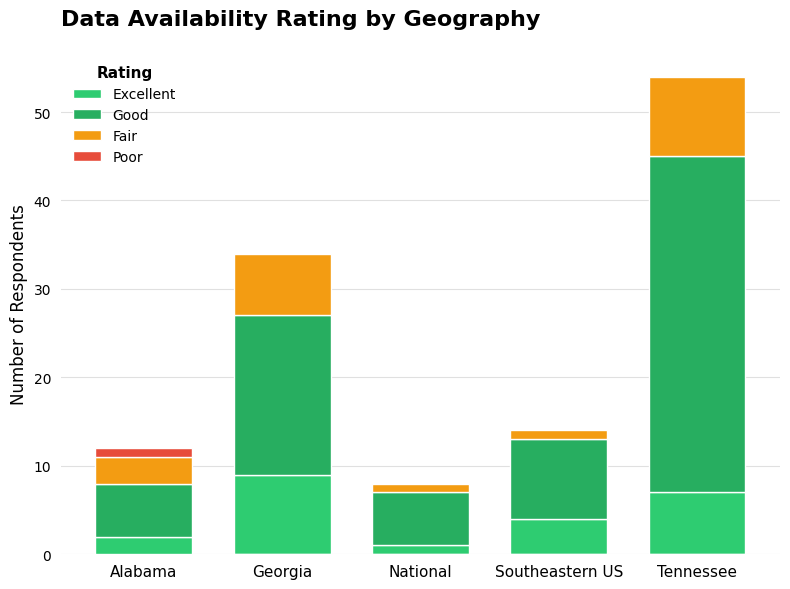

In [53]:
# ===== FIGURE 2: Data Availability Rating by Geography =====
# Splits compound geographies (TN-GA -> Tennessee, Georgia) for accurate state-level counts

import os
import matplotlib.pyplot as plt

def expand_geo(val):
    '''Split compound geographies like TN,GA or TN-GA into individual states'''
    if pd.isna(val):
        return []
    v = str(val)
    parts = v.split(',')
    expanded = []
    for p in parts:
        p = p.strip()
        if 'TN' in p and 'GA' in p and 'AL' in p:
            expanded.extend(['Tennessee', 'Georgia', 'Alabama'])
        elif 'TN' in p and 'GA' in p:
            expanded.extend(['Tennessee', 'Georgia'])
        elif p == 'Tennessee':
            expanded.append('Tennessee')
        elif p == 'Georgia':
            expanded.append('Georgia')
        elif p == 'Alabama':
            expanded.append('Alabama')
        elif p == 'National':
            expanded.append('National')
        elif p == 'Southeastern_US':
            expanded.append('Southeastern US')
        else:
            expanded.append(p)
    return expanded

rows = []
for _, row in df.iterrows():
    states = expand_geo(row['where_are_your_projects_primari'])
    for s in states:
        rows.append({'state': s, 'rating': row['rate_data_availabile']})

df_geo = pd.DataFrame(rows)

# Shorten rating labels
rating_map = {
    'Excellent - Most needed data is': 'Excellent',
    'Good - Data is available but so': 'Good',
    'Fair - Some key data is hard to': 'Fair',
    'Poor - Significant data gaps li': 'Poor'
}
df_geo['rating_short'] = df_geo['rating'].map(rating_map)

# Keep main regions
keep = ['Tennessee', 'Georgia', 'Alabama', 'National', 'Southeastern US']
df_geo = df_geo[df_geo['state'].isin(keep)]

# Crosstab and order columns
ct = pd.crosstab(df_geo['state'], df_geo['rating_short'])
desired_order = ['Excellent', 'Good', 'Fair', 'Poor']
ct = ct[[c for c in desired_order if c in ct.columns]]

# Plot
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3b']
ax = ct.plot(kind='bar', stacked=True, figsize=(8, 6), color=colors, width=0.7, edgecolor='white')

ax.set_title('Data Availability Rating by Geography', fontsize=16, fontweight='bold', pad=20, loc='left')
ax.set_xlabel('')
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_axisbelow(True)
ax.grid(True, axis='y', color='#e0e0e0', linewidth=0.8)
ax.grid(False, axis='x')
ax.tick_params(axis='x', rotation=0, labelsize=11)

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend - no border, no background, inside chart
legend = ax.legend(title='Rating', frameon=False, fontsize=10, title_fontsize=11, loc='upper left')
legend.get_title().set_fontweight('bold')
ax.tick_params( axis='both', left=False, bottom=False )
plt.tight_layout()
viz_dir = r'C:\Git_Repo\thrive-data-portal\stakeholder-map\data\visualizations'
# plt.savefig(os.path.join(viz_dir, '02_geo_vs_data_availability.png'), dpi=150, bbox_inches='tight')
print('✅ 02_geo_vs_data_availability.png saved')

In [64]:
overall_rate = df['rate_data_availabile'].str.split(" - ").str[0].value_counts().to_frame()
sum = overall_rate['count'].sum()
print( sum )

overall_rate['perc'] = [f"{i:.0%}" for i in overall_rate['count'].div(sum)]
overall_rate

77


,count,perc
rate_data_availabile,,
Good,48,62%
Fair,15,19%
Excellent,13,17%
Poor,1,1%


In [37]:
# ===== DATA USAGE PATTERNS =====

print('=== DO YOU MAINTAIN GEODATA? (single-select) ===')
print(df['do_you_maintain_geodata'].value_counts().to_string())

print('\n=== DATA SOURCE TYPES (multi-select) ===')
src = df['are_data_sources_private_public'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in src.items():
    print(f'  {str(v)[:55]:55s} : {c}')

print('\n=== FREQUENCY OF DATASET USE (single-select) ===')
print(df['how_often_have_you_used_dataset'].value_counts().to_string())

print('\n=== DATA AVAILABILITY RATING (single-select) ===')
print(df['rate_data_availabile'].value_counts().to_string())

print('\n=== PRIMARY USE OF DATA (multi-select - each choice counted separately) ===')
uses = df['what_do_you_primarily_use_data'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in uses.items():
    print(f'  {str(v)[:65]:65s} : {c}')

=== DO YOU MAINTAIN GEODATA? (single-select) ===
do_you_maintain_geodata
Yes    50
No     27

=== DATA SOURCE TYPES (multi-select) ===
  A mix of public and private                             : 43
  Mostly public                                           : 30
  Mostly private                                          : 4

=== FREQUENCY OF DATASET USE (single-select) ===
how_often_have_you_used_dataset
Frequently (most projects)      44
Occasionally (some projects)    23
Rarely                          10

=== DATA AVAILABILITY RATING (single-select) ===
rate_data_availabile
Good - Data is available but so    48
Fair - Some key data is hard to    15
Excellent - Most needed data is    13
Poor - Significant data gaps li     1

=== PRIMARY USE OF DATA (multi-select - each choice counted separately) ===
  Analysis_and_research                                             : 61
  Decision-making                                                   : 56
  Setting_organization_or_project           

In [38]:
# ===== THRIVE TOOL USAGE =====

print('=== HAVE YOU USED THRIVE TOOLS? (single-select) ===')
print(df['have_you_used_Thrive_tools'].value_counts().to_string())
thrive_users = df[df['have_you_used_Thrive_tools'] == 'Yes']
print(f'\nThrive users: {len(thrive_users)} out of {len(df)} respondents')

print('\n=== WHICH THRIVE TOOLS USED (multi-select - each tool counted separately) ===')
tools = thrive_users['which_thrive_tools_have_you_use'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in tools.items():
    print(f'  {str(v)[:55]:55s} : {c}')

print('\n=== WHEN DO YOU USE THRIVE TOOLS? (multi-select) ===')
when_use = thrive_users['when_do_you_use_Thrive_tool'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in when_use.items():
    print(f'  {str(v)[:55]:55s} : {c}')

print('\n=== HOW DO YOU ACCESS THRIVE TOOLS? (multi-select) ===')
access = thrive_users['how_do_you_access_thrive_tool'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in access.items():
    print(f'  {str(v)[:55]:55s} : {c}')

print('\n=== OTHER TOOLS/PLATFORMS USED (multi-select) ===')
other_tools = df['other_tools_or_platforms_used'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in other_tools.items():
    print(f'  {str(v)[:55]:55s} : {c}')

print('\n=== DID THRIVE PLAY A ROLE IN PROJECTS? (single-select) ===')
print(df['did_thrive_play_a_role'].value_counts().to_string())

print('\n=== CHALLENGES USING THRIVE DATA (open-ended text) ===')
challenges = df['challenges_using_thrive_data'].dropna()
print(f'Total responses: {len(challenges)}')
for i, c in enumerate(challenges):
    print(f'  {i+1}. {c[:200]}')

=== HAVE YOU USED THRIVE TOOLS? (single-select) ===
have_you_used_Thrive_tools
No     51
Yes    26

Thrive users: 26 out of 77 respondents

=== WHICH THRIVE TOOLS USED (multi-select - each tool counted separately) ===
  Interactive_Map:_Thrive_Regiona                         : 10
  Dashboard:_County_by_County_Dat                         : 10
  Dashboard:_Cradle_of_Southern_A                         : 10
  Dashboard:_Transportation_&_Inf                         : 7
  other                                                   : 1
  Interactive_Map:_Broadband_Asse                         : 1

=== WHEN DO YOU USE THRIVE TOOLS? (multi-select) ===
  Early_planning_&_scoping                                : 20
  Grant_writing_or_funding_justif                         : 11
  Monitoring_and_reporting                                : 7
  Project_design                                          : 5

=== HOW DO YOU ACCESS THRIVE TOOLS? (multi-select) ===
  Desktop_computer                             

In [39]:
# ===== FUTURE ENGAGEMENT & INTERESTS =====

print('=== INTERESTED IN FOLLOW-UP CALL? (single-select) ===')
print(df['interested_in_follup_call'].value_counts().to_string())

print('\n=== WILLING TO BETA TEST HUB? (single-select) ===')
print(df['willing_to_beta_test_hub'].value_counts().to_string())

print('\n=== WOULD YOU LIKE HUB UPDATES? (single-select) ===')
print(df['would_you_like_hub_updates'].value_counts().to_string())

print('\n=== PREFERRED REGIONAL DATA FORMATS (multi-select - each counted separately) ===')
formats = df['when_looking_at_our_region_what'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()
for v, c in formats.items():
    print(f'  {str(v):30s} : {c}')

print('\n=== MOST VALUABLE DATASETS (open-ended, top responses) ===')
datasets = df['what_dataset_most_valuable'].dropna()
print(f'Total responses: {len(datasets)}')
for i, c in enumerate(datasets.head(10)):
    print(f'  {i+1}. {c[:150]}')

=== INTERESTED IN FOLLOW-UP CALL? (single-select) ===
interested_in_follup_call
Yes    47
No     30

=== WILLING TO BETA TEST HUB? (single-select) ===
willing_to_beta_test_hub
Yes    60
No     17

=== WOULD YOU LIKE HUB UPDATES? (single-select) ===
would_you_like_hub_updates
Yes    72
No      5

=== PREFERRED REGIONAL DATA FORMATS (multi-select - each counted separately) ===
  Interactive_maps               : 71
  Dashboards                     : 54
  Impact_reports                 : 47
  Blogs                          : 11
  other                          : 3

=== MOST VALUABLE DATASETS (open-ended, top responses) ===
Total responses: 56
  1. Pacel level data maintained by the County Tax Assessor 
  2. Crash Data
  3. JobsEQ (workforce data). GISWebTech (GURU data). 
  4. US DOT
  5. Thrive
  6. USGS/State DNR Watershed Basins (HUC2 through HUC12) and National Park/Forest boundaries, Fish Counts by specific Wildlife Resource Agency by State
  7. PAD-US, ParkServe, CDC PLACES
  8. US C

## 📊 Engagement Survey: Key Insights Summary

### 1️⃣ Respondent Profile
- **77 total respondents** completed the survey
- Dominant sectors: **Conservation/Environment**, **Government/Public Administration**, **Economic/Community Development**
- Geographic scope: Mostly **multicounty/regional** and **county-level** focus
- Roles span executive directors, planners, GIS analysts, program managers, and community organizers

### 2️⃣ Data Usage Patterns
- **~60% frequently use datasets** (most projects) — data-driven culture is strong
- **~62% rate data availability as 'Good'** or 'Excellent', but 20% say 'Fair' or 'Poor'
- Top uses: **Decision-making**, **Grant writing**, **Tracking metrics/performance**, **Strategic planning**
- **~56% maintain geodata** — strong GIS capability in the network

### 3️⃣ Thrive Tool Engagement
- **Only 34%** have used Thrive tools — major opportunity for adoption growth
- Most used tools: **Interactive Map (Thrive Regional)**, **County-by-County Dashboard**, **Cradle of the South Dashboard**
- Key challenges: Navigation difficulty, limited geographic coverage, need for training, data format limitations

### 4️⃣ Future Engagement
- **61% want a follow-up call** — strong interest in deeper engagement
- **78% willing to beta test the Hub** — excellent for user testing
- **94% want Hub updates** — near-universal interest
- Top requested formats: **Interactive maps**, **Dashboards**, **Impact reports**, **Blogs**

### 5️⃣ Key Recommendations
1. **Onboarding & training** for the 66% who haven't used Thrive tools
2. **Expand geographic coverage** beyond current focus areas
3. **Improve data labeling & UI** for non-expert users (rural communities, newcomers)
4. **Prioritize interactive maps + dashboards** as primary delivery formats
5. **Leverage beta testers** (60 willing) for Hub development
6. **Address supply chain/freight data gaps** requested by economic developers